# Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!git clone --quiet --recursive https://github.com/cvg/Hierarchical-Localization/
%cd Hierarchical-Localization
!pip install --progress-bar off --quiet -e .
!pip install --progress-bar off --quiet --upgrade plotly

/content/Hierarchical-Localization
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_retrieval
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

In [8]:
DATA_PATH = Path('/content/drive/MyDrive/buggy_hloc')
IMAGES_PATH = DATA_PATH / 'images'

In [ ]:

videos = {v.stem: v for v in list(DATA_PATH.glob('*.mp4'))}
data = {}
for p in DATA_PATH.glob('vid_imu/*.json'):
    with open(p) as f:
        data[p.stem] = json.load(f)

# Create Images

In [12]:
import cv2

STRIDE = 1  # keep every Nth frame

for stem, video in tqdm(videos.items(), desc='videos'):
    start_ns = data[stem]['camera_start']  # video start, nanoseconds
    out_dir = IMAGES_PATH / stem
    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    saved = 0
    i = 0
    try:
        with tqdm(total=frame_count, desc=stem, leave=False) as progress:
            while True:
                ok, frame = cap.read()
                if not ok:
                    break
                i += 1
                progress.update(1)
                if i % STRIDE != 0:
                    continue
                timestamp_ns = start_ns + int(round(cap.get(cv2.CAP_PROP_POS_MSEC) * 1_000_000))
                cv2.imwrite(str(out_dir / f"{timestamp_ns}.jpg"), frame)
                saved += 1
    finally:
        cap.release()
    print(f"{stem}: saved {saved} frames to {out_dir}")

videos:  20%|██        | 1/5 [03:42<14:49, 222.26s/it]

37: saved 10401 frames to /content/drive/MyDrive/buggy_hloc/images/37


videos:  40%|████      | 2/5 [06:02<08:42, 174.30s/it]

38: saved 6249 frames to /content/drive/MyDrive/buggy_hloc/images/38


videos:  60%|██████    | 3/5 [09:17<06:06, 183.47s/it]

45: saved 8259 frames to /content/drive/MyDrive/buggy_hloc/images/45


videos:  80%|████████  | 4/5 [14:01<03:43, 223.20s/it]

1401: saved 12090 frames to /content/drive/MyDrive/buggy_hloc/images/1401


videos: 100%|██████████| 5/5 [16:59<00:00, 203.89s/it]

1388: saved 7714 frames to /content/drive/MyDrive/buggy_hloc/images/1388


# Config

In [41]:
outputs = Path('/content/outputs')
outputs.mkdir(exist_ok=True)
sfm_pairs = outputs / 'pairs-sfm.txt'
loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
retreival_features = outputs / 'retrieval-features.h5'
matches = outputs / 'matches.h5'

retreival_conf = extract_features.confs['netvlad']
feature_conf = extract_features.confs['disk']
matcher_conf = match_features.confs['disk+lightglue']


In [26]:
GPS_KIND, GPS_HZ, REF_STRIDE  = 'fit', 10, 2
# gps_kind = 'racebox', 25, 5

# Mapping

## Load Images

In [ ]:
vid = "45"
image_paths = sorted((IMAGES_PATH / vid).glob('*.jpg'), key=lambda p: int(p.stem))
image_ts = np.array([int(p.stem) for p in image_paths])
imu_start = data[vid]['imu_data'][0]['timestamp']

# TODO: make this based on actual distance/speed/heading
references = {
    s['timestamp']: str(image_paths[np.abs(image_ts - s['timestamp']).argmin()].relative_to(IMAGES_PATH))
    for s in data[vid]['gps_data'][::REF_STRIDE] if s['timestamp'] > imu_start
}
len(references)

726

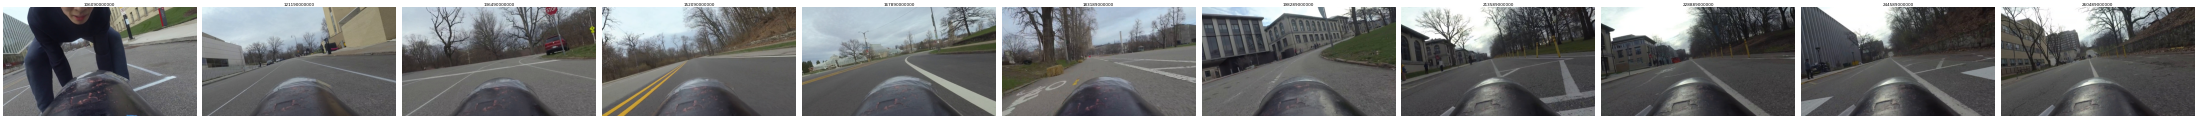

In [32]:
stride = len(references) // 10
plot_images([read_image(IMAGES_PATH / ref) for ref in list(references.values())[::stride]], 
            titles=[str(ts) for ts in list(references.keys())[::stride]], dpi=25)

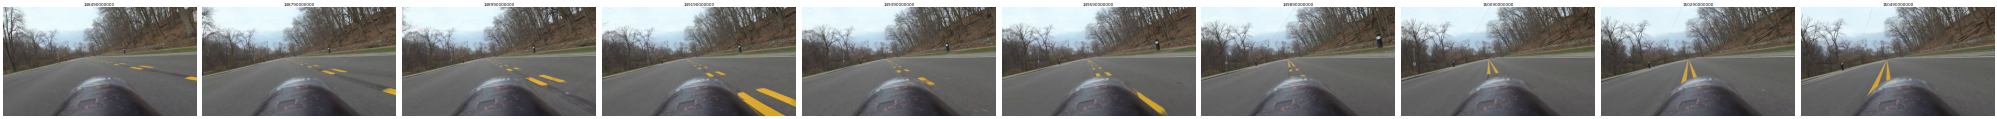

In [33]:
sl = slice(200, 210)
plot_images([read_image(IMAGES_PATH / ref) for ref in list(references.values())[sl]], 
            titles=[str(ts) for ts in list(references.keys())[sl]], dpi=25)

## Features

In [37]:
extract_features.main(feature_conf, IMAGES_PATH, image_list=list(references.values()), feature_path=features, overwrite=True)

[2026/07/03 01:34:01 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 5000, 'name': 'disk'},
 'output': 'feats-disk',
 'preprocessing': {'grayscale': False, 'resize_max': 1600}}


Downloading: "https://raw.githubusercontent.com/cvlab-epfl/disk/master/depth-save.pth" to /root/.cache/torch/hub/checkpoints/depth-save.pth


100%|██████████| 4.17M/4.17M [00:00<00:00, 85.0MB/s]
100%|██████████| 726/726 [02:42<00:00,  4.46it/s]
[2026/07/03 01:36:46 hloc INFO] Finished exporting features.


PosixPath('/content/outputs/features.h5')

In [42]:
extract_features.main(retreival_conf, IMAGES_PATH, image_list=list(references.values()), feature_path=retreival_features, overwrite=True)

[2026/07/03 01:42:55 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}


100%|██████████| 529M/529M [00:24<00:00, 22.2MB/s] 
100%|██████████| 726/726 [01:09<00:00, 10.49it/s]
[2026/07/03 01:44:44 hloc INFO] Finished exporting features.


PosixPath('/content/outputs/retrieval-features.h5')

## Matching

In [45]:
pairs_from_retrieval.main(retreival_features, sfm_pairs, num_matched=10)

[2026/07/03 01:51:54 hloc INFO] Extracting image pairs from a retrieval database.
[2026/07/03 01:51:56 hloc INFO] Found 7260 pairs.


In [46]:
match_features.main(matcher_conf, sfm_pairs, features, matches=matches, overwrite=True)

[2026/07/03 01:52:05 hloc INFO] Matching local features with configuration:
{'model': {'features': 'disk', 'name': 'lightglue'},
 'output': 'matches-disk-lightglue'}


Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/disk_lightglue.pth" to /root/.cache/torch/hub/checkpoints/disk_lightglue_v0-1_arxiv.pth


100%|██████████| 45.4M/45.4M [00:00<00:00, 245MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  0%|          | 0/4275 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if ne

PosixPath('/content/outputs/matches.h5')

## Reconstruct

In [ ]:
model = reconstruction.main(sfm_dir, IMAGES_PATH, sfm_pairs, features, matches)

[2026/07/03 02:04:04 hloc INFO] Writing COLMAP logs to /content/outputs/sfm/colmap.LOG.*
[2026/07/03 02:04:04 hloc INFO] Creating an empty database...
[2026/07/03 02:04:04 hloc INFO] Importing images into the database...


: 